# The Executive Report - Flights Dataset
#### Dataset: sns.load_dataset('flights') 
#### Goal: Take raw historical flight data and polish it into a presentation-ready graphic.
#### Themes & Contexts: Apply sns.set_style('whitegrid') to give it a clean background, and sns.set_context('talk') to automatically scale up the fonts for a presentation slide.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

flights = sns.load_dataset('flights')

sns.set_style('whitegrid')
sns.set_context('talk')

flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


#### Color Palettes: Pivot the dataset into a matrix (months vs. years) and plot a heatmap. Use sns.color_palette("Blues", as_cmap=True) so the colors intuitively map from light (few passengers) to dark (many passengers).

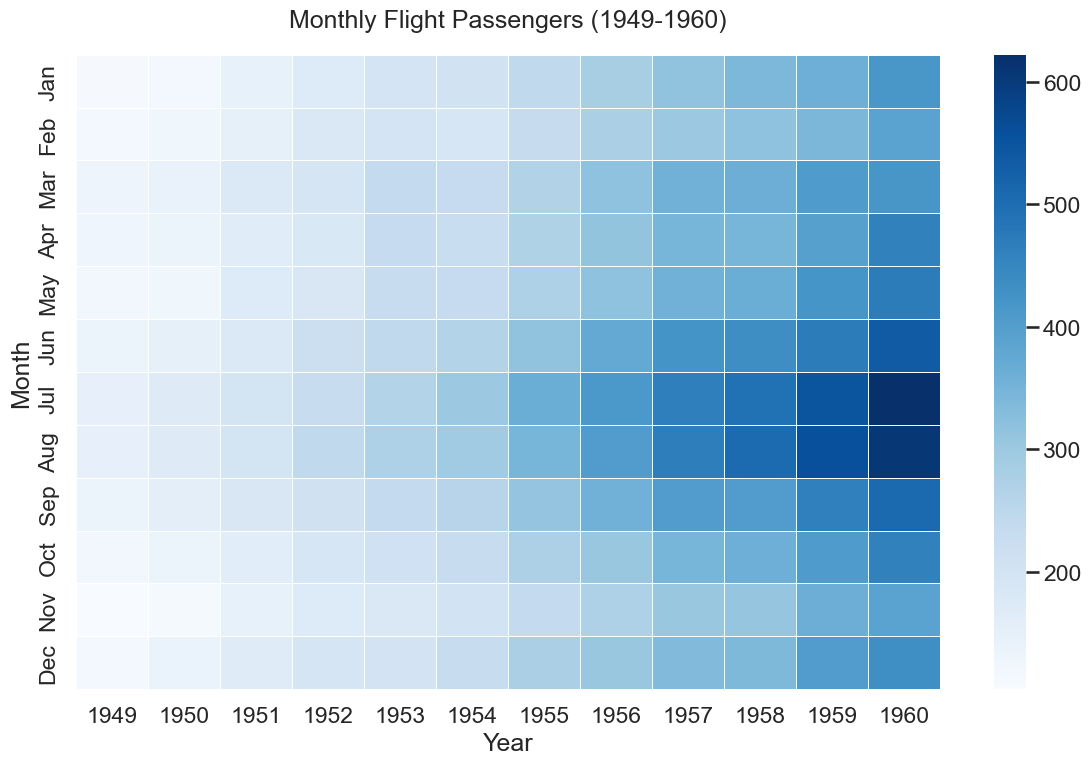

In [2]:
flights_pivot = flights.pivot(index='month', columns='year', values='passengers')

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    flights_pivot, 
    cmap=sns.color_palette("Blues", as_cmap=True), 
    linewidths=0.5
)

plt.title('Monthly Flight Passengers (1949-1960)', pad=20)
plt.ylabel('Month')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

English: This visualization is a Heatmap. Before plotting, the data was "pivoted" into a grid where rows represent months and columns represent years. The sns.heatmap function then fills this grid with colors based on the number of passengers. By using the "Blues" color palette (cmap), the colors intuitively map from light blue (months/years with fewer passengers) to dark blue (months/years with many passengers). The clean whitegrid style and talk context make the labels large and easy to read on a screen.

Observation: You can clearly see a dark blue vertical trend toward the right side (indicating overall growth over the years) and darker horizontal bands during the summer months (July/August), indicating seasonal travel spikes.

Khmer: ការបង្ហាញរូបភាពនេះគឺជា ក្រាហ្វកម្តៅ (Heatmap)។ មុនពេលគូសក្រាហ្វ ទិន្នន័យត្រូវបាន "បម្លែង (pivoted)" ទៅជាទម្រង់ម៉ាទ្រីស ដែលជួរដេកតំណាងឱ្យខែ និងជួរឈរតំណាងឱ្យឆ្នាំ។ បន្ទាប់មក អនុគមន៍ sns.heatmap បំពេញក្រឡានីមួយៗដោយពណ៌ ដោយផ្អែកលើចំនួនអ្នកដំណើរ។ តាមរយៈការប្រើប្រាស់ក្ដារពណ៌ "Blues" (cmap) ពណ៌នឹងប្រែប្រួលពីពណ៌ខៀវខ្ចី (ខែ/ឆ្នាំដែលមានអ្នកដំណើរតិច) ទៅពណ៌ខៀវចាស់ (ខែ/ឆ្នាំដែលមានអ្នកដំណើរច្រើន)។ រចនាប័ទ្ម whitegrid ដ៏ស្រឡះ និងបរិបទ talk ធ្វើឱ្យអក្សរមានទំហំធំ និងងាយស្រួលអាននៅលើអេក្រង់។

ការសង្កេត៖ អ្នកអាចមើលឃើញយ៉ាងច្បាស់នូវទំនោរពណ៌ខៀវចាស់នៅផ្នែកខាងស្តាំ (បង្ហាញពីកំណើនអ្នកដំណើរពីមួយឆ្នាំទៅមួយឆ្នាំ) និងបន្ទាត់ពណ៌ចាស់កាត់ផ្តេកនៅអំឡុងខែរដូវក្តៅ (ខែកក្កដា/សីហា) ដែលបង្ហាញពីកំណើនការធ្វើដំណើរតាមរដូវកាល។

#### Advanced Matplotlib Formatting: Plot a line chart of average passengers per year.
#### Rotate the X-axis labels (years) by 45 degrees so they are perfectly legible.
#### Use ax.set_ylim(0, 500) to force the Y-axis to start at zero instead of floating.
#### Use ax.annotate() to draw an arrow pointing to the year 1960 with the text: "Introduction of Commercial Jets".
#### Exporting: Run plt.savefig('executive_flight_report.png', dpi=300, bbox_inches='tight') to save the final, high-resolution masterpiece to their computer.Explain each of the graphs in details(both Khmer and English)

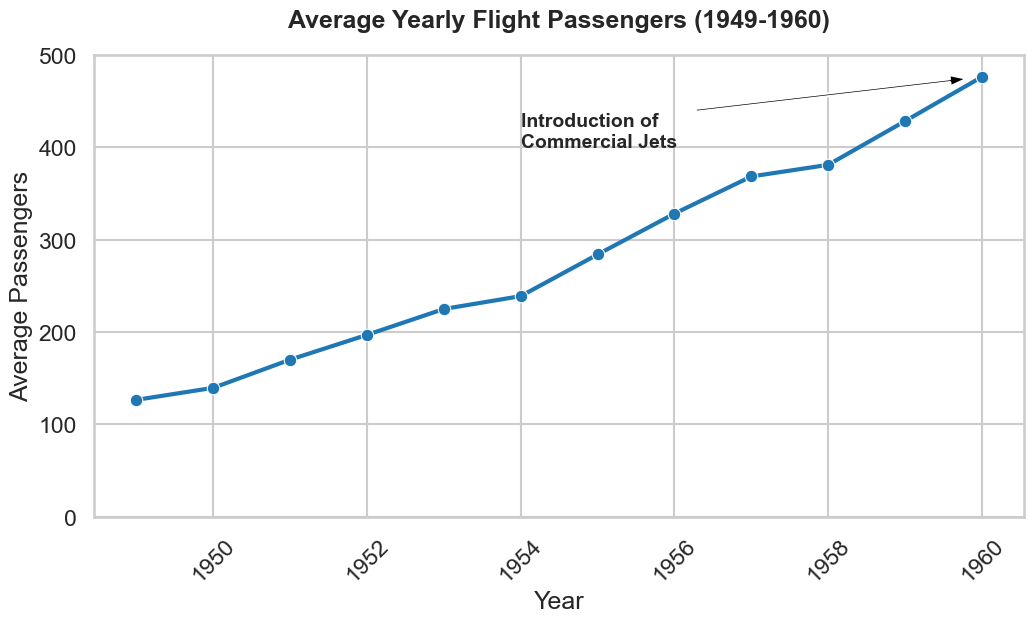

In [3]:
yearly_avg = flights.groupby('year')['passengers'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=yearly_avg, 
    x='year', 
    y='passengers', 
    ax=ax, 
    marker='o', 
    linewidth=3,
    color='#1f77b4'
)

plt.xticks(rotation=45)

ax.set_ylim(0, 500)

val_1960 = yearly_avg[yearly_avg['year'] == 1960]['passengers'].values[0]

ax.annotate(
    'Introduction of\nCommercial Jets', 
    xy=(1960, val_1960),                 # The point the arrow points TO
    xytext=(1954, 400),                  # The location of the TEXT
    arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
    fontsize=14,
    fontweight='bold'
)

plt.title('Average Yearly Flight Passengers (1949-1960)', pad=20, fontweight='bold')
plt.ylabel('Average Passengers')
plt.xlabel('Year')

plt.savefig('executive_flight_report.png', dpi=300, bbox_inches='tight')

plt.show()

English: This visualization is a Line Chart representing the average number of passengers per year. Several advanced Matplotlib formatting techniques were applied to make it "presentation-ready":

X-Axis Rotation: plt.xticks(rotation=45) tilts the years, preventing them from overlapping and making them perfectly legible.

Y-Axis Limits: ax.set_ylim(0, 500) forces the graph's bottom edge to start at 0. If left on auto, Seaborn might start the Y-axis at 100, which visually exaggerates the growth curve. Starting at zero provides a more honest representation of the data.

Annotations: ax.annotate() is used to draw attention to a specific data point (1960). This is highly effective in presentations to provide historical context or highlight key events to the audience.

Exporting: plt.savefig() saves the chart to your computer. dpi=300 ensures it is high resolution (print-quality), and bbox_inches='tight' ensures that nothing (like the rotated labels or the title) gets cut off in the final image file.

Khmer: ការបង្ហាញរូបភាពនេះគឺជា ក្រាហ្វបន្ទាត់ (Line Chart) ដែលតំណាងឱ្យចំនួនអ្នកដំណើរជាមធ្យមក្នុងមួយឆ្នាំ។ បច្ចេកទេសរៀបចំទម្រង់កម្រិតខ្ពស់របស់ Matplotlib មួយចំនួនត្រូវបានអនុវត្ត ដើម្បីធ្វើឱ្យវាស័ក្តិសមសម្រាប់ "ការធ្វើបទបង្ហាញ"៖

១. ការបង្វិលអ័ក្ស X៖ plt.xticks(rotation=45) បង្វិលឆ្នាំបញ្ឆិត ដែលជួយការពារកុំឱ្យអក្សរជាន់គ្នា និងធ្វើឱ្យវាងាយស្រួលអានបំផុត។

២. ដែនកំណត់អ័ក្ស Y៖ ax.set_ylim(0, 500) បង្ខំឱ្យគែមខាងក្រោមនៃក្រាហ្វចាប់ផ្តើមពីលេខ 0។ ប្រសិនបើទុកវាឱ្យដំណើរការដោយស្វ័យប្រវត្តិ Seaborn អាចនឹងចាប់ផ្តើមអ័ក្ស Y ពីលេខ 100 ដែលធ្វើឱ្យមើលទៅឃើញកំណើនលឿនខុសពីការពិត។ ការចាប់ផ្តើមពីលេខសូន្យ ផ្តល់នូវការបង្ហាញទិន្នន័យដែលមានភាពស្មោះត្រង់ជាងមុន។

៣. ការសរសេរបញ្ជាក់ពីលើ (Annotations)៖ ax.annotate() ត្រូវបានប្រើដើម្បីទាក់ទាញចំណាប់អារម្មណ៍ទៅលើចំណុចទិន្នន័យជាក់លាក់ណាមួយ (ឆ្នាំ ១៩៦០)។ វិធីនេះមានប្រសិទ្ធភាពខ្ពស់ក្នុងការធ្វើបទបង្ហាញ ដើម្បីផ្តល់នូវបរិបទប្រវត្តិសាស្រ្ត ឬគូសបញ្ជាក់ពីព្រឹត្តិការណ៍សំខាន់ៗដល់ទស្សនិកជន។

៤. ការទាញយក (Exporting)៖ plt.savefig() រក្សាទុកក្រាហ្វនេះទៅក្នុងកុំព្យូទ័ររបស់អ្នក។ dpi=300 ធានាថាវាជារូបភាពដែលមានគុណភាពច្បាស់ខ្លាំង (កម្រិតសម្រាប់បោះពុម្ព) ហើយ bbox_inches='tight' ធានាថាគ្មានផ្នែកណាមួយ (ដូចជាអក្សរដែលបានបង្វិល ឬចំណងជើង) ត្រូវបានកាត់ចេញនៅក្នុងឯកសាររូបភាពចុងក្រោយនោះទេ។